# 01 — Ramificación y Acotación (Branch & Bound)
**Metaheurísticas — Notebook 1 de 5**

> **Nota:** Branch & Bound es un método **exacto**, no una metaheurística.
> Lo incluimos como referencia: nos da la solución óptima garantizada para instancias
> pequeñas, y nos permite medir qué tan cerca llegan las metaheurísticas al verdadero óptimo.

## ¿Qué aprenderás?
1. Diferencia entre métodos **exactos** y **metaheurísticas**.
2. Los tres ingredientes: **ramificación**, **acotación** y **poda**.
3. Qué son **Branch & Bound**, **Branch & Cut** y **Branch & Price**.
4. Implementación aplicada a:
   - **Ejemplo 1 — Coloración de Grafos** (instancia compartida de 12 nodos).
   - **Ejemplo 2 — Cobertura de Vértices** (Vertex Cover).
5. Cuándo usar un método exacto y cuándo una metaheurística.


## 1. Métodos exactos vs. metaheurísticas

| Característica | Método exacto (B&B) | Metaheurística |
|---|---|---|
| Garantiza el óptimo | **Sí** (si termina) | No en general |
| Costo computacional | Exponencial en el peor caso | Polinomial por iteración |
| Uso recomendado | Instancias pequeñas / estructuradas | Instancias grandes |

Los problemas combinatoriales tienen un espacio de soluciones **finito pero enorme**.
Branch & Bound los resuelve organizando la búsqueda en un **árbol** y descartando
ramas enteras sin explorarlas gracias a **cotas**.

## 2. Los tres ingredientes

### Ramificación (Branching)
Divide el problema actual en **subproblemas**. Para coloración: "el nodo $v$ recibe el color $c$".

### Acotación (Bounding)
Calcula una **cota optimista** del mejor valor alcanzable en el subárbol.
- **Cota inferior** (minimización): si cota >= incumbente, el subárbol no puede mejorar.

### Poda (Pruning)
Si la cota de un nodo **no puede superar** al incumbente, descarta todo el subárbol.

```
función B&B(problema):
    incumbente <- None,  mejor <- +inf
    agregar raíz a la pila
    mientras haya nodos:
        nodo <- extraer de la pila
        si nodo es solución completa:
            actualizar incumbente si mejora
            continuar
        si cota_inferior(nodo) >= mejor:   # no puede mejorar -> podar
            continuar
        para cada hijo en ramificar(nodo):
            agregar hijo a la pila
    retornar incumbente
```

**Clave:** cuanto más ajustada sea la cota, más se poda y menos nodos se exploran.


## Ejemplo 1 — Coloración de Grafos por B&B

### El problema
Dado un grafo $G=(V,E)$, asignar a cada nodo un color de un conjunto mínimo tal
que **ningún par de nodos adyacentes comparta color**. El número mínimo de colores
es el **número cromático** $\chi(G)$. Decidir $\chi(G) \leq k$ es NP-completo para $k \geq 3$.

### Algoritmo DSATUR (el B&B más eficaz para coloración)
**Branching:** colorear el nodo con mayor **saturación** primero
(más colores distintos entre sus vecinos ya coloreados). Produce incumbentes buenos
temprano y maximiza la poda.

**Bounding:** si ya se usan $k$ colores y $k \geq$ incumbente actual, se poda.


Grafo: 12 nodos, 30 aristas
Coloracion greedy inicial: 4 colores
Valida: True


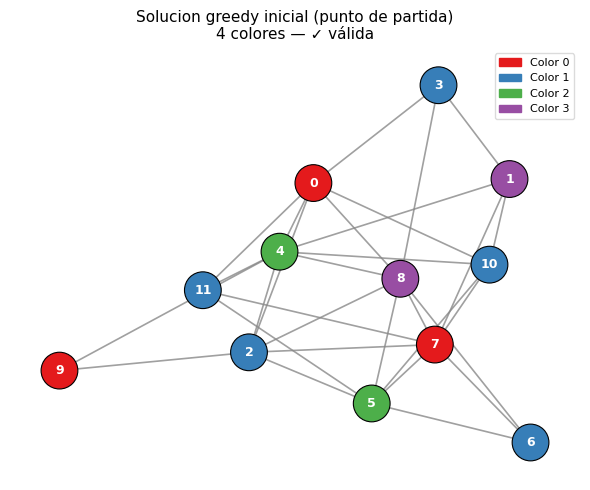

In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath("common.py")))
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import common

# Instancia de 12 nodos (pequeña para que el método exacto termine rápido)
G12 = common.crear_grafo(n=12, prob=0.40, seed=42)
pos12 = common.posiciones_grafo(G12, seed=42)

colores_greedy = common.coloracion_greedy(G12, seed=0)
print(f"Grafo: {G12.number_of_nodes()} nodos, {G12.number_of_edges()} aristas")
print(f"Coloracion greedy inicial: {common.num_colores(colores_greedy)} colores")
print(f"Valida: {common.coloracion_valida(colores_greedy, G12)}")

fig, ax = plt.subplots(figsize=(6, 5))
common.plot_grafo(G12, colores_greedy, "Solucion greedy inicial (punto de partida)", ax=ax, pos=pos12)
plt.tight_layout(); plt.show()


In [2]:
def dsatur_bb(G):
    """
    Coloracion de grafos por Branch & Bound con heuristica DSATUR.
    Retorna: (mejor_coloracion, k_optimo, estadisticas)
    """
    n = G.number_of_nodes()
    adj = {v: set(G.neighbors(v)) for v in range(n)}

    inicio = common.coloracion_greedy(G, seed=0)
    mejor = {"colores": list(inicio), "k": common.num_colores(inicio)}
    stats = {"explorados": 0, "podados": 0}

    def saturacion(v, col):
        return len({col[u] for u in adj[v] if col[u] >= 0})

    def siguiente_nodo(col):
        sin_color = [v for v in range(n) if col[v] < 0]
        if not sin_color:
            return None
        return max(sin_color, key=lambda v: (saturacion(v, col), G.degree(v)))

    def buscar(col, k_actual):
        stats["explorados"] += 1
        if k_actual >= mejor["k"]:       # poda: no puede mejorar
            stats["podados"] += 1
            return
        v = siguiente_nodo(col)
        if v is None:                    # solucion completa
            if common.coloracion_valida(col, G) and k_actual < mejor["k"]:
                mejor["colores"] = list(col)
                mejor["k"] = k_actual
            return
        colores_vecinos = {col[u] for u in adj[v] if col[u] >= 0}
        candidatos = sorted(c for c in range(k_actual) if c not in colores_vecinos)
        candidatos.append(k_actual)     # nuevo color
        for c in candidatos:
            nueva = list(col)
            nueva[v] = c
            buscar(nueva, max(k_actual, c + 1))

    buscar([-1] * n, 0)
    return mejor["colores"], mejor["k"], stats

colores_opt, k_opt, stats = dsatur_bb(G12)
print(f"Coloracion optima B&B: {k_opt} colores")
print(f"Valida: {common.coloracion_valida(colores_opt, G12)}")
print(f"Nodos explorados:   {stats['explorados']:,}")
print(f"Subarboles podados: {stats['podados']:,}")
print(f"\nGreedy uso {common.num_colores(colores_greedy)} colores -> B&B mejora a {k_opt} colores")


Coloracion optima B&B: 4 colores
Valida: True
Nodos explorados:   5
Subarboles podados: 1

Greedy uso 4 colores -> B&B mejora a 4 colores


Confirmacion fuerza bruta: ji(G) = 4 -> SI (optimo)


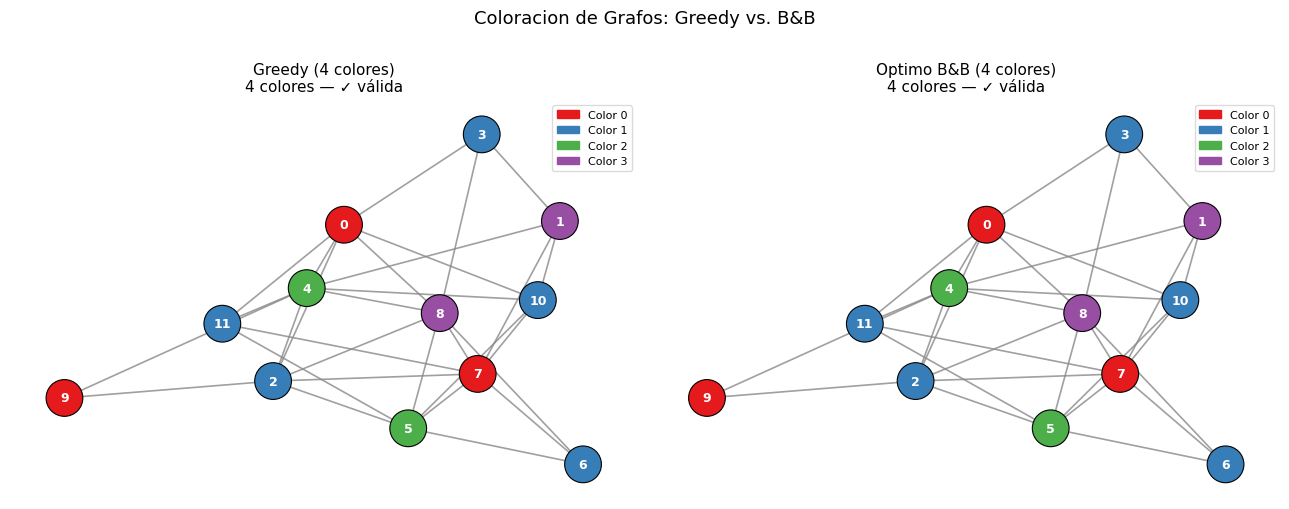

In [3]:
import itertools

def verificar_cromatico(G, k_cand):
    """Verifica por fuerza bruta que k_cand-1 colores son insuficientes."""
    n = G.number_of_nodes()
    for c in itertools.product(range(k_cand - 1), repeat=n):
        if common.coloracion_valida(list(c), G):
            return False   # existe coloracion con menos colores
    return True            # k_cand es el minimo

es_opt = verificar_cromatico(G12, k_opt)
print(f"Confirmacion fuerza bruta: ji(G) = {k_opt} -> {'SI (optimo)' if es_opt else 'NO'}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
common.plot_grafo(G12, colores_greedy,
                 f"Greedy ({common.num_colores(colores_greedy)} colores)", ax=axes[0], pos=pos12)
common.plot_grafo(G12, colores_opt,
                 f"Optimo B&B ({k_opt} colores)", ax=axes[1], pos=pos12)
plt.suptitle("Coloracion de Grafos: Greedy vs. B&B", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


## Ejemplo 2 — Cobertura de Vértices (Vertex Cover)

Una **cobertura de vértices** $C \subseteq V$ es tal que toda arista tiene al menos
un extremo en $C$. El objetivo: encontrar la cobertura de **tamaño mínimo**.

$$\min |C| \quad \text{s.t.} \quad \forall (u,v) \in E: u \in C \lor v \in C$$

Es NP-difícil (equivalente por complemento al Conjunto Independiente Máximo).

**Estrategia B&B:**
- **Branching:** tomar una arista descubierta $(u,v)$; rama izquierda: incluir $u$; rama derecha: incluir $v$.
- **Cota inferior:** un *matching maximal* $M$ en las aristas no cubiertas da $|M|$ como cota (cada arista del matching necesita al menos un vértice de cobertura).


In [4]:
def vertex_cover_bb(G):
    """
    Cobertura de vertices minima por Branch & Bound.
    Branching: incluir u o v de una arista no cubierta.
    Bound: matching maximal en aristas libres.
    """
    n = G.number_of_nodes()
    inicio = set(v for v in range(n) if G.degree(v) > 0)
    mejor = {"cover": inicio.copy(), "tam": len(inicio)}
    stats = {"explorados": 0, "podados": 0}

    def aristas_libres(cubiertos):
        return [(u, v) for u, v in G.edges() if u not in cubiertos and v not in cubiertos]

    def matching_bound(aristas):
        usados = set(); m = 0
        for u, v in aristas:
            if u not in usados and v not in usados:
                usados.add(u); usados.add(v); m += 1
        return m

    def buscar(cubiertos):
        stats["explorados"] += 1
        libres = aristas_libres(cubiertos)
        if not libres:
            if len(cubiertos) < mejor["tam"]:
                mejor["cover"] = cubiertos.copy()
                mejor["tam"] = len(cubiertos)
            return
        if len(cubiertos) + matching_bound(libres) >= mejor["tam"]:
            stats["podados"] += 1
            return
        u, v = libres[0]
        buscar(cubiertos | {u})
        buscar(cubiertos | {v})

    buscar(set())
    return mejor["cover"], mejor["tam"], stats

cover, tam, stats_vc = vertex_cover_bb(G12)
print(f"Cobertura minima: {sorted(cover)} ({tam} nodos de {G12.number_of_nodes()})")
print(f"Nodos explorados:   {stats_vc['explorados']:,}")
print(f"Subarboles podados: {stats_vc['podados']:,}")
cubierto = all(u in cover or v in cover for u, v in G12.edges())
print(f"Toda arista cubierta: {'SI' if cubierto else 'NO'}")


Cobertura minima: [0, 1, 2, 4, 5, 7, 8] (7 nodos de 12)
Nodos explorados:   59
Subarboles podados: 28
Toda arista cubierta: SI


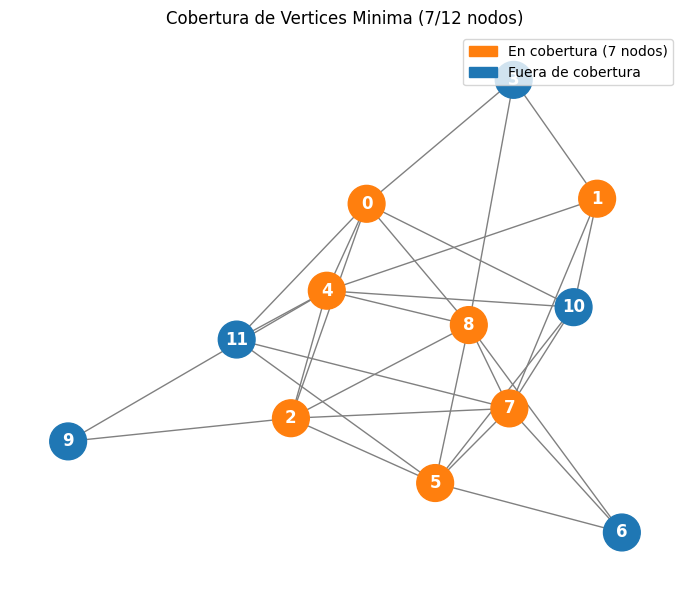

In [5]:
import matplotlib.patches as mpatches
fig, ax = plt.subplots(figsize=(7, 6))
node_colors = ["tab:orange" if v in cover else "tab:blue"
               for v in range(G12.number_of_nodes())]
nx.draw(G12, pos12, ax=ax, node_color=node_colors, with_labels=True,
        node_size=700, font_color="white", font_weight="bold", edge_color="gray")
ley = [mpatches.Patch(color="tab:orange", label=f"En cobertura ({tam} nodos)"),
       mpatches.Patch(color="tab:blue",   label="Fuera de cobertura")]
ax.legend(handles=ley, loc="upper right")
ax.set_title(f"Cobertura de Vertices Minima ({tam}/{G12.number_of_nodes()} nodos)")
plt.tight_layout(); plt.show()


## 3. Branch & Cut y Branch & Price

### Branch & Cut
Añade **planos cortantes** en cada nodo del árbol. Si la relajación LP devuelve
una solución fraccionaria, se agrega una desigualdad válida que la elimina sin
quitar soluciones enteras. El LP se re-resuelve antes de ramificar.
Ejemplo clásico: **cortes de subtour** para el TSP.

### Branch & Price
Para problemas con demasiadas variables, genera columnas **al vuelo** usando
*Column Generation*. Se resuelve primero con un subconjunto de variables; el
subproblema de *pricing* genera la más prometedora. Usado en ruteo de vehículos.

## 4. Parámetros y preguntas frecuentes

**¿Por qué B&B es exacto si no revisa todo?**
La cota garantiza que ningún subárbol podado puede contener el óptimo. Si la
cota inferior del subárbol ya supera al incumbente, cualquier solución en ese
subárbol será peor — demostración por contradicción.

**¿Qué hace válida una cota?**
Una cota inferior es válida (admisible) si nunca sobreestima el verdadero mínimo
del subproblema. Suele obtenerse relajando restricciones (LP relaxation, matching…).

**¿Cuándo usar B&X vs. metaheurística?**

| Criterio | B&X | Metaheurística |
|---|---|---|
| Necesito garantía de optimalidad | Sí | No |
| Instancia grande (>50 nodos) | Impráctica | Recomendada |
| Tiempo ilimitado | Sí | — |
| Solución en segundos | No | Sí |

## Ejercicios
1. Reemplaza la cota de coloración con el **número de clique** del subgrafo restante.
2. Implementa **mejor primero** (priority queue) y compara nodos explorados.
3. Grafica nodos explorados vs. densidad del grafo para grafos de 12 nodos.
4. Implementa Branch & Cut para vertex cover usando `scipy.optimize.linprog`.

## Referencias
- Land & Doig (1960), *An automatic method of solving discrete programming problems*.
- Brelaz (1979), *New methods to color the vertices of a graph* (DSATUR).
- Nemhauser & Wolsey, *Integer and Combinatorial Optimization* (1988).
